# 🔬 Precision Fluid-Bed Pellet Image Processing & Classification
### *Depth-of-Field Blur Removal, Overlap Discrimination & Agglomeration Detection*

---

### 📋 Overview & Problem Statement
In industrial fluid-bed imaging systems with high-magnification macro lenses:
1. **Narrow Depth of Field (DoF)**: Zooming into a specific Region of Interest (ROI) / focal plane means particles moving in front of or behind the focal volume appear as **large, diffuse, blurred bokeh blobs**. These out-of-focus particles must be accurately detected and filtered out.
2. **Sharp / Visible Pellets**: Only pellets in the focal slice have high edge gradient sharpness and distinct textural/boundary features.
3. **Multi-Pellet Configurations**:
   - 🟢 **Far (Isolated Single)**: Separated pellets with no physical or optical neighbor interaction.
   - 🔵 **Overlapped (Optical 2D Occlusion)**: Distinct pellets passing each other at different depths or touching along the camera line of sight (displaying internal occlusion boundaries / depth contrast).
   - 🟠 **Connected (Physically Agglomerated)**: Pellets physically bound/fused together sharing a common neck/bridge with continuous surface gradient.

---
### 🛠️ Pipeline Architecture
```
[Raw BMP Image] 
       │
       ▼
[ROI Cropping & CLAHE Enhancement] 
       │
       ▼
[Focus / Sharpness Metric Computation] ────► [Reject Blurred Bokeh Pellets]
       │
       ▼ (Visible / In-Focus Only)
[Distance Transform + Watershed + Hough Detection]
       │
       ▼
[Geometric & Occlusion Edge Analysis]
       ├─► Far / Single Pellets
       ├─► Overlapped Pellets (Optical Occlusion)
       └─► Connected Pellets (Physical Agglomerates)
       │
       ▼
[Particle Size Distribution (D10, D50, D90) & Granulometry Metrics]
```


## 📦 Step 1: Environment Setup & Core Libraries
Load required computer vision, scientific computing, and visualization packages.

In [1]:
import os
import cv2
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import ndimage
from skimage.feature import peak_local_max
from skimage.segmentation import watershed

# Configure Matplotlib styling
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10

# Optical & Calibration constants (industrial fluid-bed camera)
FOV_WIDTH_MM = 30.0           # Horizontal Field of View (mm)
UM_PER_PX    = 14.65          # 14.65 µm per pixel (at 2048x1536 sensor)
MM_PER_PX    = UM_PER_PX / 1000.0  # 0.01465 mm per pixel

# Default sample path provided by user
SAMPLE_PATH = r"C:\Users\user\Desktop\Computer Vision\Real-Data\exp 1000 back+ext light early agg\Pic_20260914110617199-244.bmp"

print("Libraries loaded successfully.")
print(f"Calibration: {UM_PER_PX:.2f} um/px | FOV: {FOV_WIDTH_MM} mm")
print(f"Target sample: {os.path.basename(SAMPLE_PATH)} (Exists: {os.path.exists(SAMPLE_PATH)})")

Libraries loaded successfully.
Calibration: 14.65 um/px | FOV: 30.0 mm
Target sample: Pic_20260914110617199-244.bmp (Exists: True)


## 🖼️ Step 2: Image Loading & Fluid-Bed Stream ROI Selection
Industrial fluid bed images contain static metal chamber walls, mounting poles, and bottom container flanges.
We define a Region of Interest (ROI) covering the active fluid bed stream to ignore stationary equipment.

Active Stream ROI shape: 1230x1000 px


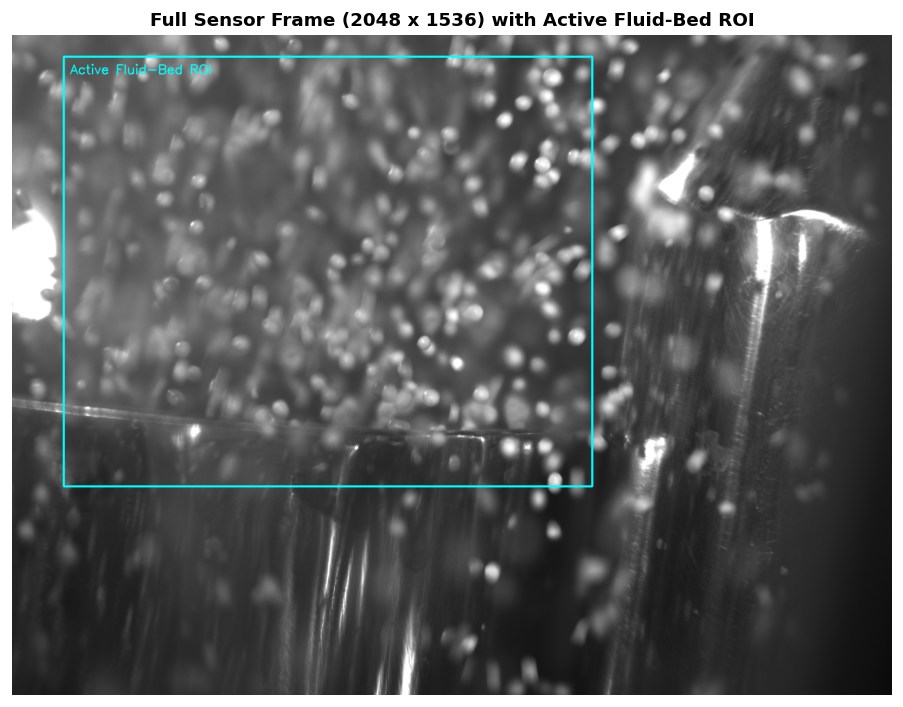

In [2]:
# Load original image
raw_bgr = cv2.imread(SAMPLE_PATH)
if raw_bgr is None:
    raise FileNotFoundError(f"Could not load image: {SAMPLE_PATH}")

raw_gray = cv2.cvtColor(raw_bgr, cv2.COLOR_BGR2GRAY)
img_h, img_w = raw_gray.shape

# Fluid Bed Active Stream ROI
# Default ROI excludes:
# - Left illumination glare: x < 120
# - Right metallic support column: x > 1350
# - Bottom container wall/flange: y > 1050
ROI_X1, ROI_X2 = 120, 1350
ROI_Y1, ROI_Y2 = 50, 1050

roi_gray = raw_gray[ROI_Y1:ROI_Y2, ROI_X1:ROI_X2]
roi_bgr = raw_bgr[ROI_Y1:ROI_Y2, ROI_X1:ROI_X2]

# Visualize sensor view with ROI box
fig, ax = plt.subplots(figsize=(10, 6))
vis_full = cv2.cvtColor(raw_gray, cv2.COLOR_GRAY2RGB)
cv2.rectangle(vis_full, (ROI_X1, ROI_Y1), (ROI_X2, ROI_Y2), (0, 255, 255), 3)
cv2.putText(vis_full, "Active Fluid-Bed ROI", (ROI_X1 + 15, ROI_Y1 + 40),
            cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 255), 2)

ax.imshow(vis_full)
ax.set_title(f"Full Sensor Frame ({img_w} x {img_h}) with Active Fluid-Bed ROI", fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

print(f"Active Stream ROI shape: {roi_gray.shape[1]}x{roi_gray.shape[0]} px")

## ⚡ Step 3: Contrast Enhancement & Differential Operators
To reliably isolate sharp pellets from soft out-of-focus background blobs:
1. **CLAHE (Contrast Limited Adaptive Histogram Equalization)**: Normalizes dynamic range across non-uniform fluid-bed lighting.
2. **Bilateral Filter**: Smooths fine high-frequency sensor noise while preserving sharp particle edge transitions.
3. **Sobel Gradient Operator (Tenengrad)**: Computes the spatial gradient magnitude $\sqrt{G_x^2 + G_y^2}$.
4. **Laplacian Operator**: Evaluates local curvature and high-frequency edge variance.

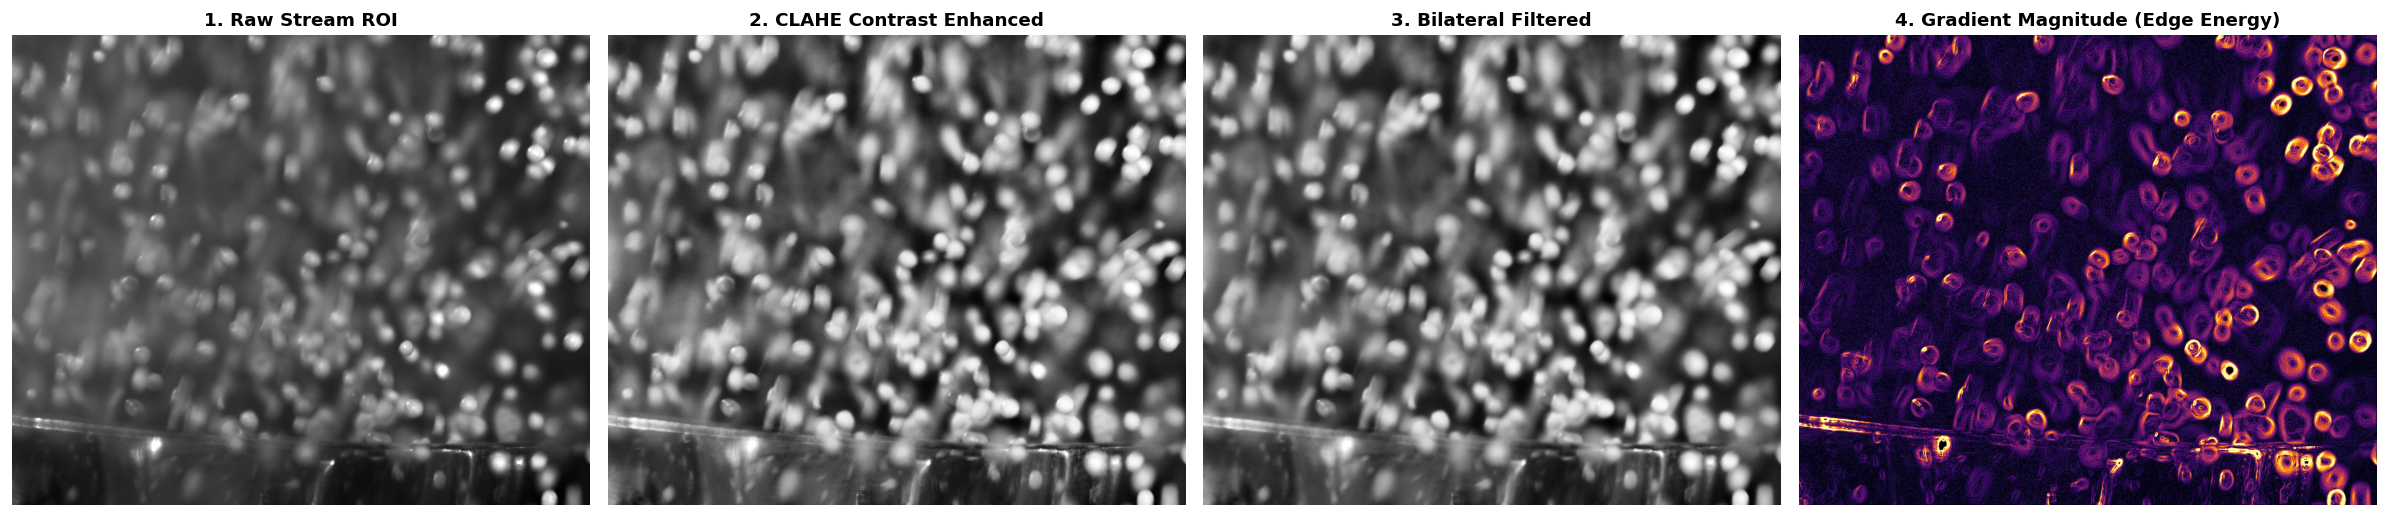

In [3]:
# 1. CLAHE Contrast Enhancement
clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
enhanced = clahe.apply(roi_gray)

# 2. Edge-Preserving Bilateral Smoothing
bilateral = cv2.bilateralFilter(enhanced, d=7, sigmaColor=50, sigmaSpace=50)

# 3. Sobel Gradient Magnitude (Tenengrad focus energy)
sobelx = cv2.Sobel(roi_gray, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(roi_gray, cv2.CV_64F, 0, 1, ksize=3)
grad_mag = np.sqrt(sobelx**2 + sobely**2)

# 4. Laplacian Operator (High-frequency curvature)
laplacian = cv2.Laplacian(roi_gray, cv2.CV_64F, ksize=3)

# 4-Panel Visualization
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(roi_gray, cmap='gray')
axes[0].set_title("1. Raw Stream ROI", fontweight='bold')
axes[0].axis('off')

axes[1].imshow(enhanced, cmap='gray')
axes[1].set_title("2. CLAHE Contrast Enhanced", fontweight='bold')
axes[1].axis('off')

axes[2].imshow(bilateral, cmap='gray')
axes[2].set_title("3. Bilateral Filtered", fontweight='bold')
axes[2].axis('off')

axes[3].imshow(np.clip(grad_mag * 2.5, 0, 255), cmap='inferno')
axes[3].set_title("4. Gradient Magnitude (Edge Energy)", fontweight='bold')
axes[3].axis('off')

plt.tight_layout()
plt.show()

## 🎯 Step 4: Multi-Scale Candidate Pellet Detection
Pellets in this optical configuration have an expected radius of **10 to 32 pixels** (~0.3 to 1.0 mm).
We detect all candidate pellet circular bounds (both in-focus and out-of-focus) across the active stream.

In [4]:
# Detect candidate pellet locations using Circular Hough Transform
HOUGH_DP         = 1.2
HOUGH_MIN_DIST   = 15   # Min distance between centers (pixels)
HOUGH_PARAM1     = 60   # Canny edge high threshold
HOUGH_PARAM2     = 23   # Accumulator voting threshold
MIN_RADIUS_PX    = 10   # ~0.30 mm
MAX_RADIUS_PX    = 32   # ~0.95 mm

raw_circles = cv2.HoughCircles(
    bilateral,
    cv2.HOUGH_GRADIENT,
    dp=HOUGH_DP,
    minDist=HOUGH_MIN_DIST,
    param1=HOUGH_PARAM1,
    param2=HOUGH_PARAM2,
    minRadius=MIN_RADIUS_PX,
    maxRadius=MAX_RADIUS_PX
)

candidates = []
if raw_circles is not None:
    raw_circles = np.uint16(np.around(raw_circles[0]))
    for (cx, cy, r_u) in raw_circles:
        cx, cy, r = int(cx), int(cy), int(r_u)
        if cy - r < 0 or cy + r >= roi_gray.shape[0] or cx - r < 0 or cx + r >= roi_gray.shape[1]:
            continue
        candidates.append({'cx': cx, 'cy': cy, 'r': r})

print(f"Total candidate spheres detected: {len(candidates)}")

Total candidate spheres detected: 141


## 🔍 Step 5: Depth-of-Field Blur Measurement & Rejection Engine

### Mathematical Focus Criteria
For each candidate pellet $P_i$ at $(c_x, c_y, r)$:
1. **Perimeter Boundary Sharpness ($S_{edge}$)**:
   Mean gradient magnitude evaluated along the circular boundary ring:
   $$S_{edge} = \frac{1}{|R|} \sum_{(x,y) \in R} \|\nabla I(x,y)\|$$
   where $R = \{ (x,y) : r - 2 \le \|(x,y) - (c_x, c_y)\| \le r + 2 \}$.
2. **Internal Specular & Texture Variance ($V_{lap}$)**:
   High-frequency variance of the Laplacian within the pellet interior:
   $$V_{lap} = \mathrm{Var}\Big( \nabla^2 I(x,y) \Big) \quad \forall (x,y) \text{ where } \|(x,y) - (c_x, c_y)\| < r - 2$$
3. **Composite Focus Score ($F$)**:
   $$F = 0.70 \cdot S_{edge} + 0.30 \cdot \sqrt{V_{lap}}$$

Pellets with $F < \text{FOCUS\_THRESHOLD}$ lie outside the optical focal plane and are **rejected as blurred bokeh**.

Sharp / In-Focus Pellets Kept: 38 (27.0%)
Blurred / Out-of-Focus Rejected: 103 (73.0%)


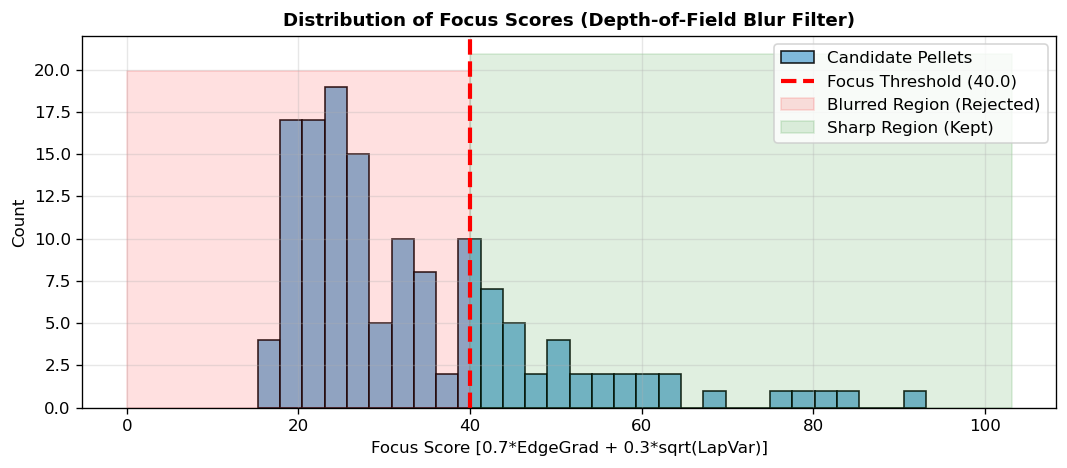

In [5]:
# Evaluate sharpness / focus metric for each candidate
FOCUS_THRESHOLD = 40.0   # Cutoff score: >= 40 is in-focus, < 40 is blurred

evaluated_pellets = []
h_roi, w_roi = roi_gray.shape

for c in candidates:
    cx, cy, r = c['cx'], c['cy'], c['r']
    
    y_grid, x_grid = np.ogrid[-r:r+1, -r:r+1]
    dist = np.sqrt(x_grid**2 + y_grid**2)
    
    inner_mask = dist <= (r - 2)
    ring_mask  = (dist >= (r - 2)) & (dist <= (r + 2))
    outer_mask = (dist >= (r + 4)) & (dist <= (r + 8))
    
    patch_grad = grad_mag[cy-r:cy+r+1, cx-r:cx+r+1]
    patch_lap  = laplacian[cy-r:cy+r+1, cx-r:cx+r+1]
    patch_gray = roi_gray[cy-r:cy+r+1, cx-r:cx+r+1]
    
    if patch_grad.shape != inner_mask.shape:
        continue
        
    edge_sharpness = np.mean(patch_grad[ring_mask]) if np.any(ring_mask) else 0.0
    lap_var        = np.var(patch_lap[inner_mask]) if np.any(inner_mask) else 0.0
    inner_mean     = np.mean(patch_gray[inner_mask]) if np.any(inner_mask) else 0.0
    outer_mean     = np.mean(patch_gray[outer_mask]) if np.any(outer_mask) else 0.0
    contrast       = inner_mean - outer_mean
    
    focus_score = (edge_sharpness * 0.70) + (np.sqrt(lap_var) * 0.30)
    is_sharp    = focus_score >= FOCUS_THRESHOLD
    
    diam_px = 2.0 * r
    diam_um = diam_px * UM_PER_PX
    diam_mm = diam_px * MM_PER_PX
    area_px = math.pi * (r ** 2)
    
    evaluated_pellets.append({
        'cx': cx,
        'cy': cy,
        'r': r,
        'diam_px': diam_px,
        'diam_um': diam_um,
        'diam_mm': diam_mm,
        'area_px': area_px,
        'edge_sharpness': round(edge_sharpness, 2),
        'lap_var': round(lap_var, 2),
        'focus_score': round(focus_score, 2),
        'is_sharp': is_sharp,
        'contrast': round(contrast, 2)
    })

sharp_pellets   = [p for p in evaluated_pellets if p['is_sharp']]
blurred_pellets = [p for p in evaluated_pellets if not p['is_sharp']]

print(f"Sharp / In-Focus Pellets Kept: {len(sharp_pellets)} ({len(sharp_pellets)/len(evaluated_pellets)*100:.1f}%)")
print(f"Blurred / Out-of-Focus Rejected: {len(blurred_pellets)} ({len(blurred_pellets)/len(evaluated_pellets)*100:.1f}%)")

# Focus Distribution Plot
all_scores = [p['focus_score'] for p in evaluated_pellets]
plt.figure(figsize=(9, 4))
plt.hist(all_scores, bins=30, color='#6baed6', edgecolor='black', alpha=0.85, label='Candidate Pellets')
plt.axvline(FOCUS_THRESHOLD, color='red', linestyle='--', linewidth=2.5, label=f'Focus Threshold ({FOCUS_THRESHOLD})')
plt.fill_betweenx([0, plt.ylim()[1]], 0, FOCUS_THRESHOLD, color='red', alpha=0.12, label='Blurred Region (Rejected)')
plt.fill_betweenx([0, plt.ylim()[1]], FOCUS_THRESHOLD, max(all_scores)+10, color='green', alpha=0.12, label='Sharp Region (Kept)')
plt.title("Distribution of Focus Scores (Depth-of-Field Blur Filter)", fontweight='bold')
plt.xlabel("Focus Score [0.7*EdgeGrad + 0.3*sqrt(LapVar)]")
plt.ylabel("Count")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 🔬 Step 6: Distinguish Far, Overlapped, and Connected Pellets

### Physical & Optical Discrimination Criteria
We construct an interaction adjacency graph across all retained sharp pellets:
1. **Center Distance Ratio**:
   $$\rho_{ij} = \frac{d(c_i, c_j)}{r_i + r_j} = \frac{\sqrt{(x_i - x_j)^2 + (y_i - y_j)^2}}{r_i + r_j}$$
   - If $\rho_{ij} > 1.15$: **No interaction** $\rightarrow$ the pellets are separated in space.
   - If $\rho_{ij} \le 1.15$: **Interaction exists** (either Overlapped or Connected).

2. **🟢 Far (Isolated Single Pellets)**:
   - Pellets with no neighbor interaction within $1.15 \times (r_i + r_j)$.
   - Freely fluidized, round, unperturbed single pellets.

3. **🔵 Overlapped Pellets (Optical 2D Line-of-Sight Occlusion)**:
   - Pellets intersecting along the optical projection axis.
   - **Internal Occlusion Edge**: The front pellet's boundary creates a prominent edge / gradient step cutting through the intersection region.
   - **Depth / Focus Disparity**: Because they pass at slightly different depths, their focus scores often differ ($|F_i - F_j| > \tau$).
   - **Deep Geometric Overlap**: Distance ratio $\rho_{ij} < 0.82$.

4. **🟠 Connected Pellets (Physically Agglomerated / Touching)**:
   - Pellets touching at their surfaces ($0.82 \le \rho_{ij} \le 1.15$) forming a liquid or sintered neck bridge.
   - **Continuous Intensity Bridge**: No sharp internal occlusion line dividing them.
   - **Identical Focal Plane**: Both pellets have matching focus scores ($|F_i - F_j| \le \tau$).

In [6]:
canny = cv2.Canny(roi_gray, 40, 100)

n_sharp = len(sharp_pellets)
interaction_labels = ["far"] * n_sharp
partner_graph = [[] for _ in range(n_sharp)]

# 1. Build Interaction Graph
for i in range(n_sharp):
    p1 = sharp_pellets[i]
    for j in range(i + 1, n_sharp):
        p2 = sharp_pellets[j]
        dx = p1['cx'] - p2['cx']
        dy = p1['cy'] - p2['cy']
        dist = np.sqrt(dx**2 + dy**2)
        r_sum = p1['r'] + p2['r']
        
        if dist <= r_sum * 1.15:
            partner_graph[i].append((j, dist, r_sum))
            partner_graph[j].append((i, dist, r_sum))

# 2. Classify Interaction Type
for i in range(n_sharp):
    p1 = sharp_pellets[i]
    if not partner_graph[i]:
        interaction_labels[i] = "far"
    else:
        is_overlapped = False
        for (j, dist, r_sum) in partner_graph[i]:
            p2 = sharp_pellets[j]
            ratio = dist / r_sum
            
            num_samples = 15
            xs = np.linspace(p1['cx'], p2['cx'], num_samples).astype(int)
            ys = np.linspace(p1['cy'], p2['cy'], num_samples).astype(int)
            
            xs = np.clip(xs, 0, w_roi - 1)
            ys = np.clip(ys, 0, h_roi - 1)
            
            mid_canny = canny[ys[4:11], xs[4:11]]
            mid_grads = grad_mag[ys[4:11], xs[4:11]]
            
            has_internal_edge = np.any(mid_canny > 0) or (np.max(mid_grads) > 35.0)
            focus_diff = abs(p1['focus_score'] - p2['focus_score'])
            
            if ratio < 0.82 or (has_internal_edge and ratio < 0.95 and focus_diff > 12.0):
                is_overlapped = True
                break
                
        interaction_labels[i] = "overlapped" if is_overlapped else "connected"

for i, p in enumerate(sharp_pellets):
    p['category'] = interaction_labels[i]

counts = pd.Series(interaction_labels).value_counts().to_dict()
far_cnt = counts.get('far', 0)
ovl_cnt = counts.get('overlapped', 0)
con_cnt = counts.get('connected', 0)

print("=" * 55)
print("CLASSIFICATION BREAKDOWN:")
print(f"   [Far / Single Pellets]:        {far_cnt:3d}  ({far_cnt/n_sharp*100:5.1f}%)")
print(f"   [Overlapped Pellets]:          {ovl_cnt:3d}  ({ovl_cnt/n_sharp*100:5.1f}%)")
print(f"   [Connected / Agglomerated]:    {con_cnt:3d}  ({con_cnt/n_sharp*100:5.1f}%)")
print("-" * 55)
print(f"   Total Sharp Pellets Analyzed:  {n_sharp:3d}")
print("=" * 55)

CLASSIFICATION BREAKDOWN:
   [Far / Single Pellets]:         28  ( 73.7%)
   [Overlapped Pellets]:            4  ( 10.5%)
   [Connected / Agglomerated]:      6  ( 15.8%)
-------------------------------------------------------
   Total Sharp Pellets Analyzed:   38


## 🎨 Step 7: Master Annotated Visualization
Overlay detected pellets with color-coded classification:
- 🟢 **Green**: Far / Isolated Single Pellets
- 🔵 **Blue**: Overlapped Pellets
- 🟠 **Orange**: Connected / Agglomerated Pellets
- 🔴 **Faint Red**: Blurred Bokeh (Filtered Out)

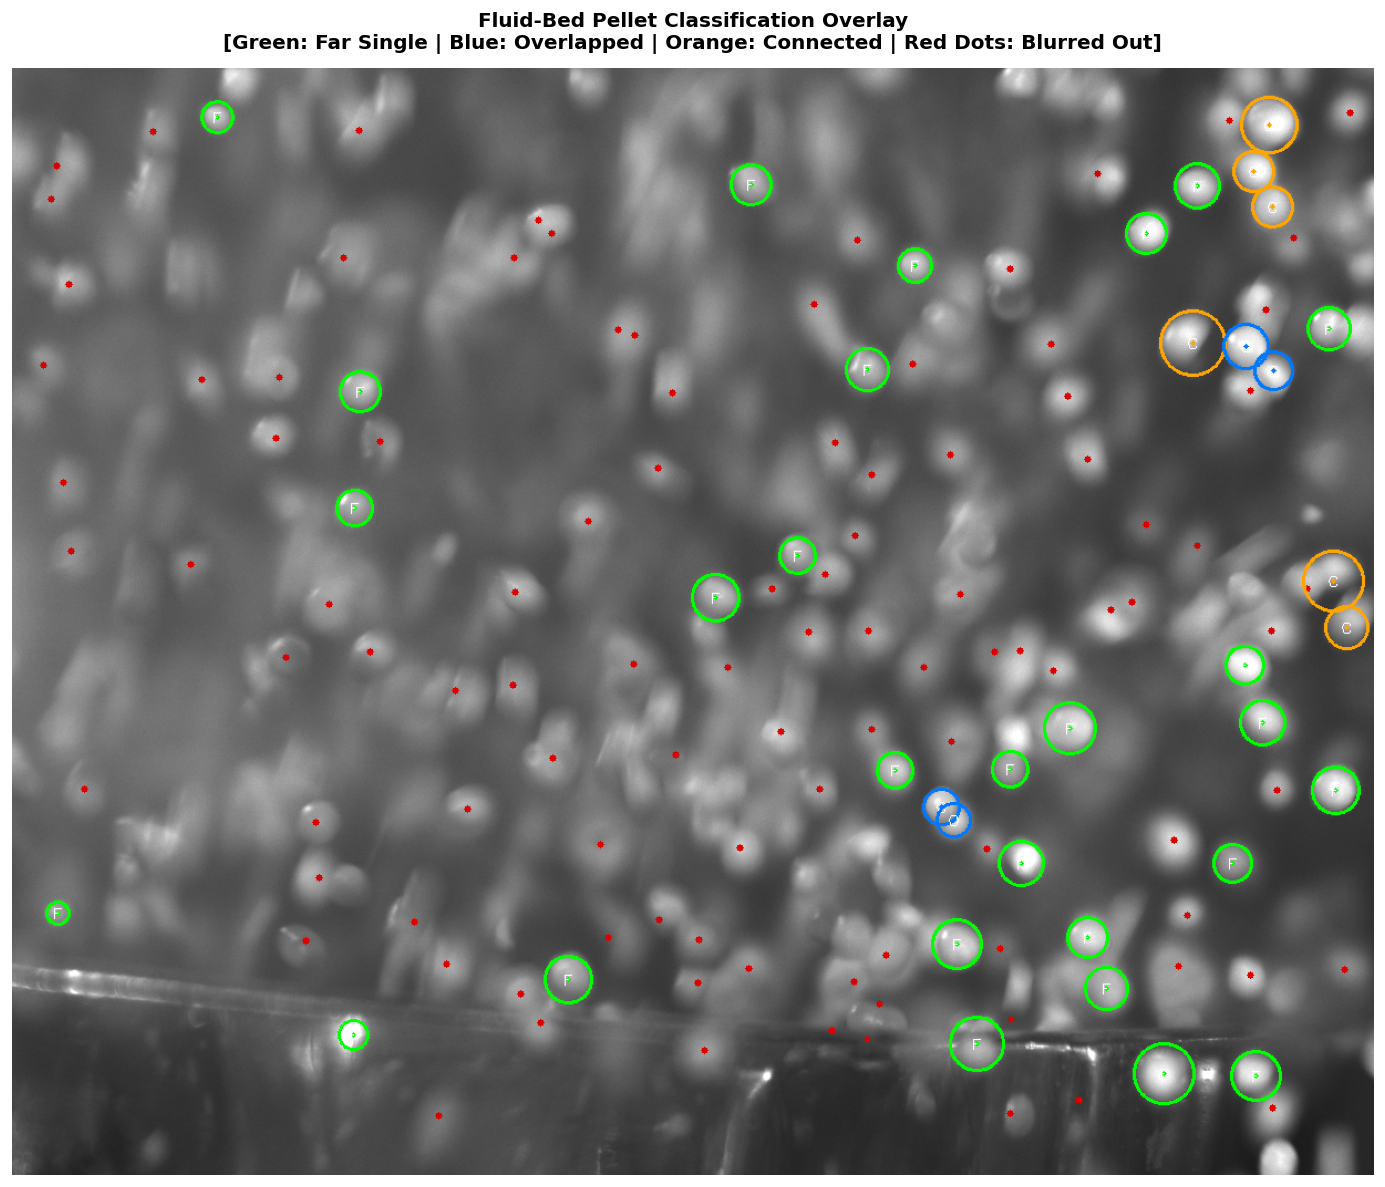

In [7]:
vis_master = roi_bgr.copy()

COLOR_MAP = {
    'far':        (0, 255, 0),    # Green
    'overlapped': (255, 120, 0),  # Blue / Cyan
    'connected':  (0, 165, 255)   # Amber / Orange
}

# 1. Draw Blurred Pellets (Filtered out) as subtle red markers
for bp in blurred_pellets:
    cv2.circle(vis_master, (bp['cx'], bp['cy']), 3, (0, 0, 220), -1)

# 2. Draw Sharp Pellets
for p in sharp_pellets:
    cat = p['category']
    color = COLOR_MAP[cat]
    cx, cy, r = p['cx'], p['cy'], p['r']
    
    cv2.circle(vis_master, (cx, cy), r, color, 2)
    cv2.circle(vis_master, (cx, cy), 2, color, -1)
    
    tag = cat[0].upper() # 'F', 'O', 'C'
    cv2.putText(vis_master, tag, (cx - 5, cy + 5), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1)

vis_rgb = cv2.cvtColor(vis_master, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(figsize=(14, 10))
ax.imshow(vis_rgb)
ax.set_title("Fluid-Bed Pellet Classification Overlay\n[Green: Far Single | Blue: Overlapped | Orange: Connected | Red Dots: Blurred Out]", 
             fontsize=12, fontweight='bold', pad=12)
ax.axis('off')
plt.tight_layout()
plt.show()

## 🔎 Step 8: High-Detail Diagnostic Inspection Gallery
Detailed zoomed-in crops comparing representative instances of:
1. **Far / Single In-Focus Pellet**
2. **Blurred / Out-of-Focus Bokeh Blob**
3. **Overlapped Pellets Pair**
4. **Connected / Agglomerated Pellets Cluster**

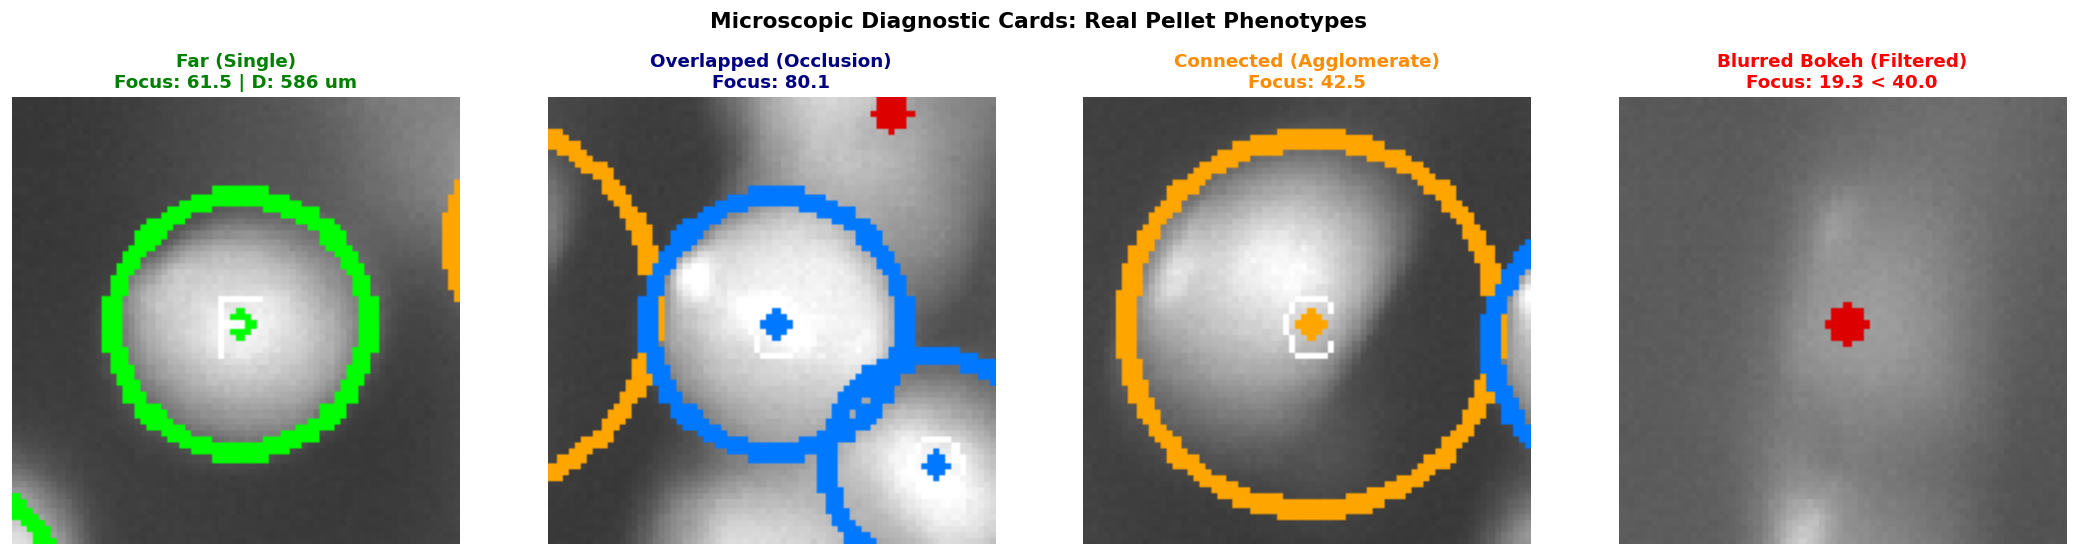

In [8]:
def extract_square_crop(img, cx, cy, size=70):
    half = size // 2
    y1 = max(0, cy - half)
    y2 = min(img.shape[0], cy + half)
    x1 = max(0, cx - half)
    x2 = min(img.shape[1], cx + half)
    crop = img[y1:y2, x1:x2]
    return cv2.resize(crop, (150, 150), interpolation=cv2.INTER_NEAREST)

ex_far = next((p for p in sharp_pellets if p['category'] == 'far'), None)
ex_ovl = next((p for p in sharp_pellets if p['category'] == 'overlapped'), None)
ex_con = next((p for p in sharp_pellets if p['category'] == 'connected'), None)
ex_blr = blurred_pellets[len(blurred_pellets)//2] if blurred_pellets else None

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

if ex_far:
    axes[0].imshow(cv2.cvtColor(extract_square_crop(vis_master, ex_far['cx'], ex_far['cy']), cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Far (Single)\nFocus: {ex_far['focus_score']:.1f} | D: {ex_far['diam_um']:.0f} um", fontweight='bold', color='green')
axes[0].axis('off')

if ex_ovl:
    axes[1].imshow(cv2.cvtColor(extract_square_crop(vis_master, ex_ovl['cx'], ex_ovl['cy']), cv2.COLOR_BGR2RGB))
    axes[1].set_title(f"Overlapped (Occlusion)\nFocus: {ex_ovl['focus_score']:.1f}", fontweight='bold', color='navy')
axes[1].axis('off')

if ex_con:
    axes[2].imshow(cv2.cvtColor(extract_square_crop(vis_master, ex_con['cx'], ex_con['cy']), cv2.COLOR_BGR2RGB))
    axes[2].set_title(f"Connected (Agglomerate)\nFocus: {ex_con['focus_score']:.1f}", fontweight='bold', color='darkorange')
axes[2].axis('off')

if ex_blr:
    axes[3].imshow(cv2.cvtColor(extract_square_crop(vis_master, ex_blr['cx'], ex_blr['cy']), cv2.COLOR_BGR2RGB))
    axes[3].set_title(f"Blurred Bokeh (Filtered)\nFocus: {ex_blr['focus_score']:.1f} < {FOCUS_THRESHOLD}", fontweight='bold', color='red')
axes[3].axis('off')

plt.suptitle("Microscopic Diagnostic Cards: Real Pellet Phenotypes", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 📊 Step 9: Granulometric Size Distribution ($D_{10}, D_{50}, D_{90}$)
Computes the industry-standard cumulative particle size distribution (PSD) for the visible pellets.

GRANULOMETRY & PARTICLE SIZE DISTRIBUTION (PSD):
   D10: 439.5 um (0.440 mm)
   D50: 542.0 um (0.542 mm) [Median Diameter]
   D90: 712.0 um (0.712 mm)
   Span (D90-D10)/D50: 0.50

First 5 Detected Sharp Pellets:


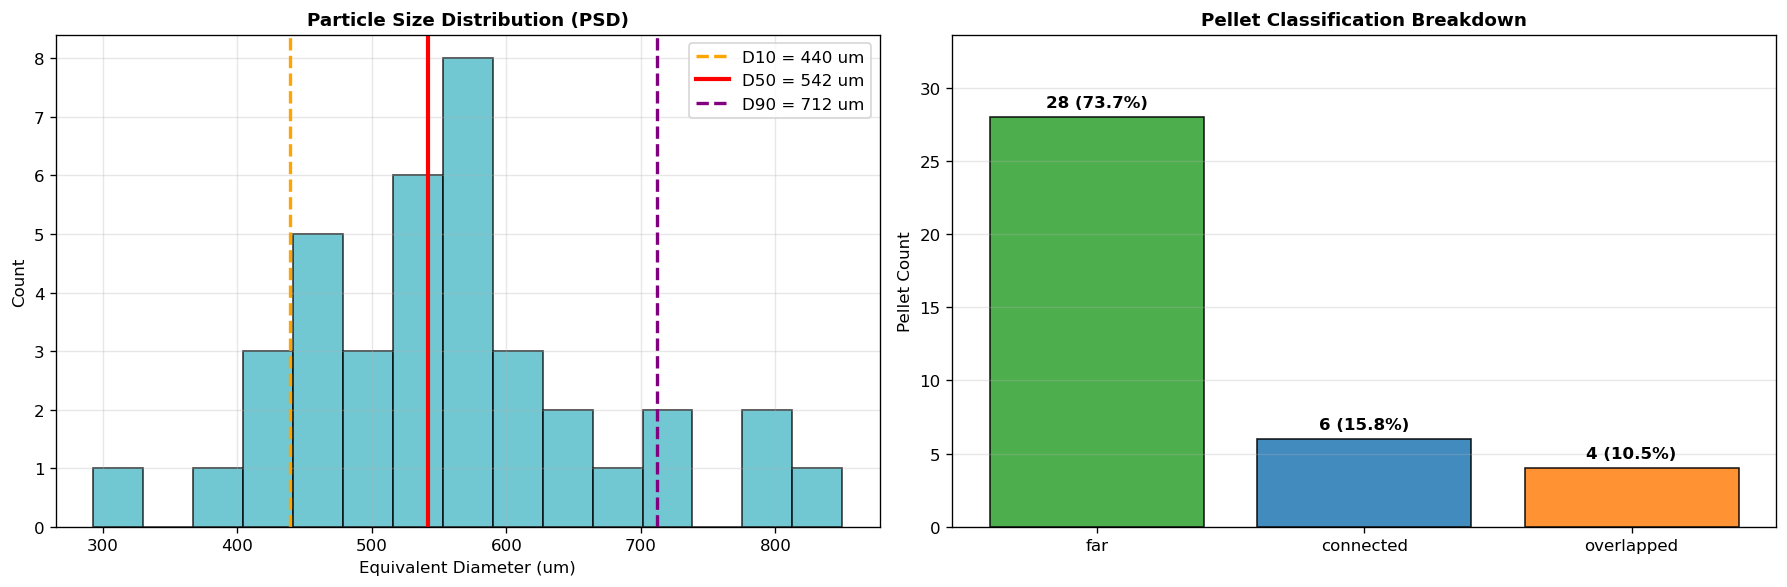

,cx,cy,r,diam_um,focus_score,category
0,1070,106,20,586.0,61.50,far
1,309,397,16,468.8,62.23,far
2,1040,908,27,791.1,41.90,far
3,1123,910,22,644.6,52.12,far
4,1066,248,29,849.7,42.51,connected


In [9]:
df_pellets = pd.DataFrame(sharp_pellets)

diams_um = np.sort(df_pellets['diam_um'].values)
d10 = np.percentile(diams_um, 10)
d50 = np.percentile(diams_um, 50)
d90 = np.percentile(diams_um, 90)

print("=" * 55)
print("GRANULOMETRY & PARTICLE SIZE DISTRIBUTION (PSD):")
print(f"   D10: {d10:.1f} um ({d10/1000:.3f} mm)")
print(f"   D50: {d50:.1f} um ({d50/1000:.3f} mm) [Median Diameter]")
print(f"   D90: {d90:.1f} um ({d90/1000:.3f} mm)")
print(f"   Span (D90-D10)/D50: {(d90 - d10)/d50:.2f}")
print("=" * 55)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# PSD Histogram
ax1.hist(diams_um, bins=15, color='#41b6c4', edgecolor='black', alpha=0.75, density=False)
ax1.axvline(d10, color='orange', linestyle='--', linewidth=2, label=f'D10 = {d10:.0f} um')
ax1.axvline(d50, color='red', linestyle='-', linewidth=2.5, label=f'D50 = {d50:.0f} um')
ax1.axvline(d90, color='purple', linestyle='--', linewidth=2, label=f'D90 = {d90:.0f} um')
ax1.set_title("Particle Size Distribution (PSD)", fontweight='bold')
ax1.set_xlabel("Equivalent Diameter (um)")
ax1.set_ylabel("Count")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Category Breakdown Bar Chart
cat_counts = df_pellets['category'].value_counts()
colors = ['#2ca02c', '#1f77b4', '#ff7f0e']
bars = ax2.bar(cat_counts.index, cat_counts.values, color=colors, edgecolor='black', alpha=0.85)
for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2.0, yval + 0.5, f"{int(yval)} ({yval/len(df_pellets)*100:.1f}%)", ha='center', va='bottom', fontweight='bold')
ax2.set_title("Pellet Classification Breakdown", fontweight='bold')
ax2.set_ylabel("Pellet Count")
ax2.set_ylim(0, max(cat_counts.values) * 1.2)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nFirst 5 Detected Sharp Pellets:")
display(df_pellets[['cx', 'cy', 'r', 'diam_um', 'focus_score', 'category']].head())

## 🚀 Step 10: Reusable Processing Function & Batch Pipeline
A clean standalone function `process_fluidbed_frame` to process any image or run across all folders in `Real-Data`.

In [10]:
def process_fluidbed_frame(image_path, focus_thresh=40.0, roi=(120, 1350, 50, 1050)):
    """
    Complete image processing pipeline for industrial fluid-bed frames:
    - Filters out blurred/bokeh pellets outside the focal depth
    - Separates and classifies sharp pellets into Far, Overlapped, and Connected
    - Computes real-world granulometry (um)
    """
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Cannot read image: {image_path}")
        
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    x1, x2, y1, y2 = roi
    roi_gray = gray[y1:y2, x1:x2]
    
    # CLAHE + Bilateral
    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
    enhanced = clahe.apply(roi_gray)
    smooth = cv2.bilateralFilter(enhanced, 7, 50, 50)
    
    # Gradients
    sobelx = cv2.Sobel(roi_gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(roi_gray, cv2.CV_64F, 0, 1, ksize=3)
    grad_mag = np.sqrt(sobelx**2 + sobely**2)
    laplacian = cv2.Laplacian(roi_gray, cv2.CV_64F, ksize=3)
    canny = cv2.Canny(roi_gray, 40, 100)
    
    # Candidate circles
    circles = cv2.HoughCircles(smooth, cv2.HOUGH_GRADIENT, dp=1.2, minDist=15, param1=60, param2=23, minRadius=10, maxRadius=32)
    if circles is None:
        return pd.DataFrame()
        
    circles = np.uint16(np.around(circles[0]))
    sharp = []
    
    for (cx, cy, r_u) in circles:
        cx, cy, r = int(cx), int(cy), int(r_u)
        if cy - r < 0 or cy + r >= roi_gray.shape[0] or cx - r < 0 or cx + r >= roi_gray.shape[1]:
            continue
        y_grid, x_grid = np.ogrid[-r:r+1, -r:r+1]
        dist = np.sqrt(x_grid**2 + y_grid**2)
        inner_mask = dist <= (r - 2)
        ring_mask  = (dist >= (r - 2)) & (dist <= (r + 2))
        
        patch_grad = grad_mag[cy-r:cy+r+1, cx-r:cx+r+1]
        patch_lap  = laplacian[cy-r:cy+r+1, cx-r:cx+r+1]
        if patch_grad.shape != inner_mask.shape: continue
        
        edge_sharp = np.mean(patch_grad[ring_mask]) if np.any(ring_mask) else 0.0
        lap_var    = np.var(patch_lap[inner_mask]) if np.any(inner_mask) else 0.0
        focus_score = (edge_sharp * 0.70) + (np.sqrt(lap_var) * 0.30)
        
        if focus_score >= focus_thresh:
            sharp.append({
                'cx': cx, 'cy': cy, 'r': r,
                'diam_um': 2.0 * r * UM_PER_PX,
                'focus_score': round(focus_score, 1)
            })
            
    # Classify interactions
    n = len(sharp)
    labels = ["far"] * n
    for i in range(n):
        for j in range(i + 1, n):
            dist = np.sqrt((sharp[i]['cx'] - sharp[j]['cx'])**2 + (sharp[i]['cy'] - sharp[j]['cy'])**2)
            r_sum = sharp[i]['r'] + sharp[j]['r']
            if dist <= r_sum * 1.15:
                ratio = dist / r_sum
                xs = np.clip(np.linspace(sharp[i]['cx'], sharp[j]['cx'], 15).astype(int), 0, roi_gray.shape[1]-1)
                ys = np.clip(np.linspace(sharp[i]['cy'], sharp[j]['cy'], 15).astype(int), 0, roi_gray.shape[0]-1)
                has_edge = np.any(canny[ys[4:11], xs[4:11]] > 0)
                diff = abs(sharp[i]['focus_score'] - sharp[j]['focus_score'])
                
                cat = "overlapped" if (ratio < 0.82 or (has_edge and diff > 12.0)) else "connected"
                labels[i] = cat
                labels[j] = cat
                
    for i in range(n):
        sharp[i]['category'] = labels[i]
        
    return pd.DataFrame(sharp)

# Quick demonstration of the pipeline function
df_test = process_fluidbed_frame(SAMPLE_PATH)
print(f"Pipeline function executed successfully. Processed {len(df_test)} sharp pellets.")
print(df_test['category'].value_counts())

Pipeline function executed successfully. Processed 38 sharp pellets.
category
far           28
overlapped     5
connected      5
Name: count, dtype: int64
